
--- Running MCMC ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'gamma_pl', 'sigma_beta_E']


100%|██████████| 1500/1500 [02:44<00:00,  9.13it/s]


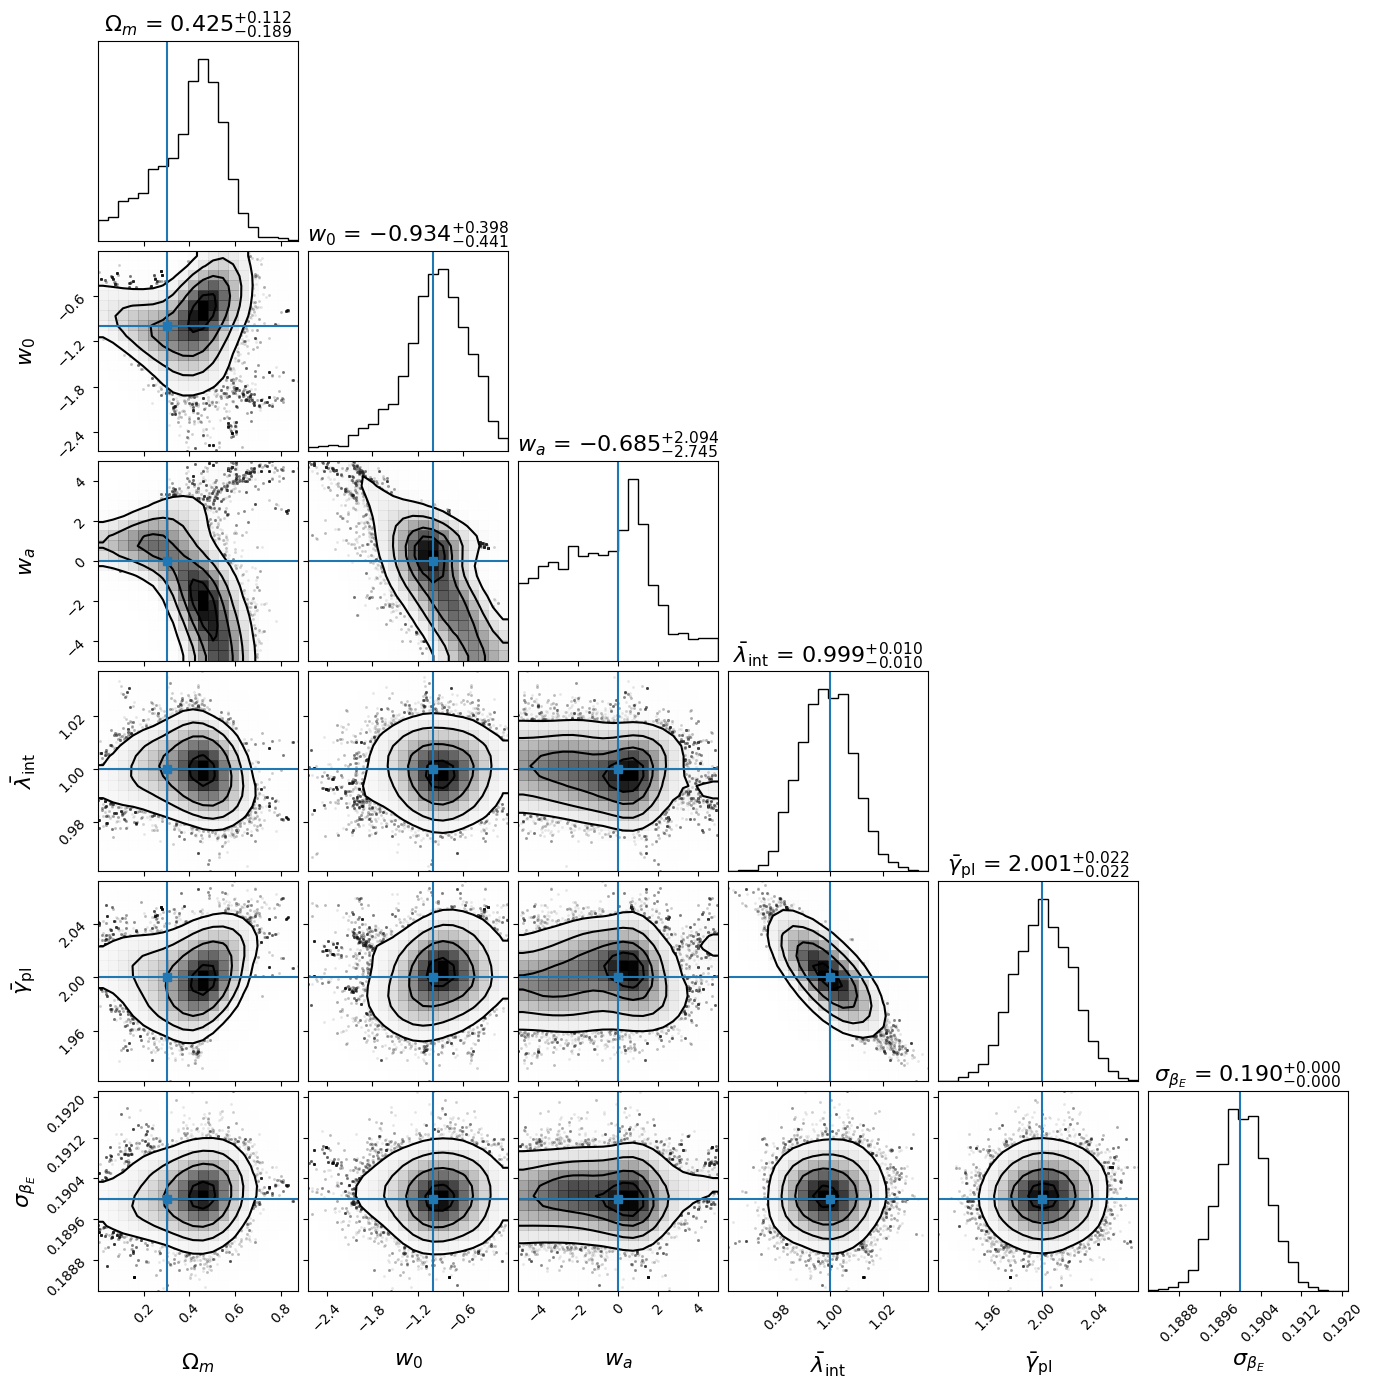

In [5]:
import numpy as np
from astropy.cosmology import Flatw0waCDM
from dspl_inference_beta_E_scatter import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt

# 1. SETUP SIMPLIFIED TRUTH 
# (Defines the exact scalar truth for our unified parameter)
truth = {
    'h0': 70.0, 
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'gamma_pl': 2.0, 
    'sigma_beta_E': 0.19 
}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# 2. GENERATE MOCK ASIMOV DATA
kwargs_list = []
num_lenses = 1000
down_sampling = 86

for _ in range(num_lenses):
    z_lens = np.random.normal(loc=0.5, scale=0.1)
    z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
    z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
    
    # Calculate known observational/LOS uncertainties separately
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], 
        gamma_pl_mean=truth['gamma_pl'], 
        sigma_beta_E_true=truth['sigma_beta_E'], # Pass the exact truth here
        sigma_meas_rel=sigma_meas_rel, 
        down_sampling=down_sampling, 
        with_noise=False, # True for Noisy, False for Asimov
        cosmo=cosmo_true,
        redshift_error_rel=0.03
    ))

# 3. CONFIGURE MCMC INFERENCE
# Fix cosmology parameter H0 to test purely structural/scatter capability
fixed_params = {'h0': 70.0}

my_guess = {
    'om': 0.3, 
    'w0': -1.0, 
    'wa': 0.0,
    'lambda_int': 1.0, 
    'gamma_pl': 2.0, 
    'sigma_beta_E': 0.021
}

my_spreads = {
    'om': 0.05, 
    'w0': 0.05, 
    'wa': 0.05,
    'lambda_int': 0.05, 
    'gamma_pl': 0.05, 
    'sigma_beta_E': 0.02
}

# 4. RUN INFERENCE
print("\n--- Running MCMC ---")
samples, labels = run_dspl_inference(
    kwargs_list,
    n_walkers=32, n_steps=1500, n_burn=500,
    initial_guess=my_guess, 
    initial_scatter=my_spreads,
    fixed_params=fixed_params,
    down_sampling=down_sampling,
)

# 5. PLOT CORNER
full_truths_list = [
    truth['om'], 
    truth['w0'], 
    truth['wa'], 
    truth['lambda_int'], 
    truth['gamma_pl'], 
    truth['sigma_beta_E']
]

fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".3f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)

plt.show()

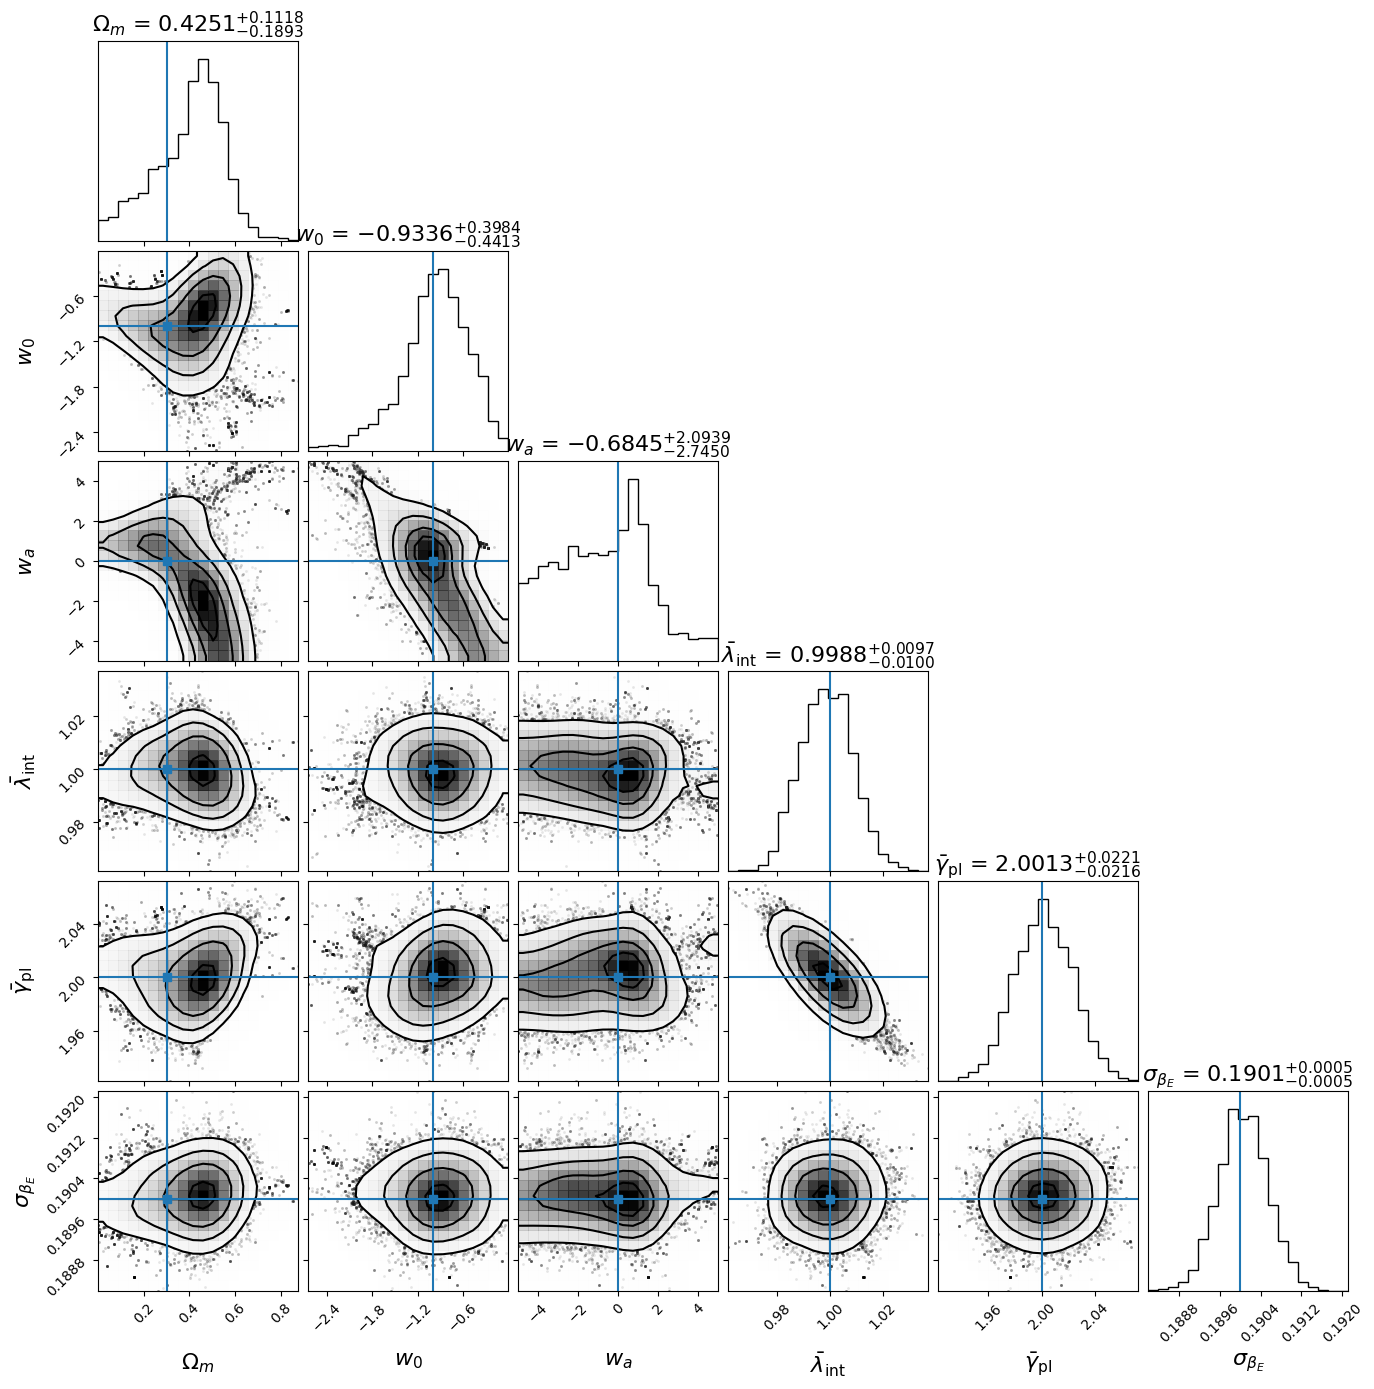

In [6]:
fig = corner.corner(
    samples, 
    labels=labels, 
    truths=full_truths_list,
    truth_color="#1f77b4",
    smooth=1.5,
    show_titles=True,
    title_fmt=".4f", 
    title_kwargs={"fontsize": 16},  
    label_kwargs={"fontsize": 16} 
)